In [1]:
import tools

In [2]:
import time

In [3]:
tools.ext.np.set_printoptions(precision=8, suppress=True, floatmode="fixed")

In [4]:
! dcm2niix -b y "../../../sourcedata/sub-1/ses-2/Serie3/"

Chris Rorden's dcm2niiX version v1.0.20220720  (JP2:OpenJPEG) GCC13.2.0 x86-64 (64-bit Linux)
Found 1009 DICOM file(s)
Convert 1009 DICOM as ../../../sourcedata/sub-1/ses-2/Serie3/Serie3_Unknown_[1]_(2630)_20240920125610_2630c (512x512x1009x1)
Conversion required 3.813679 seconds (2.341829 for core code).


In [5]:
fn1 = "../../../sourcedata/sub-1/ses-2/Serie3/Serie3_Unknown_[1]_(2630)_20240920125610_2630.nii"
vol1 = tools.ext.nib.load(fn1)

In [6]:
A1 = vol1.get_fdata()
aff1 = vol1.affine
print(A1.shape)

(512, 512, 1009)


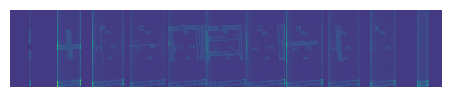

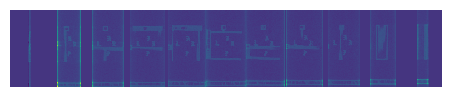

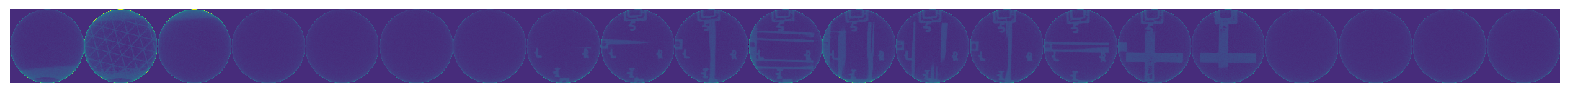

In [7]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A1, mode, 50, decimate=5); 

(512, 512, 509)


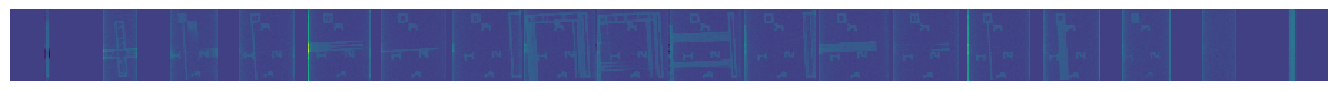

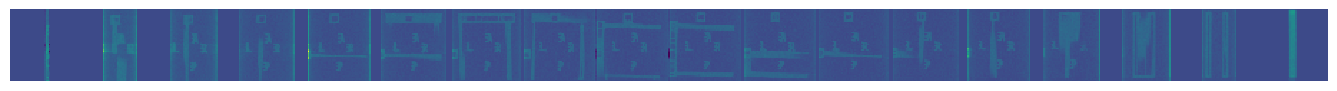

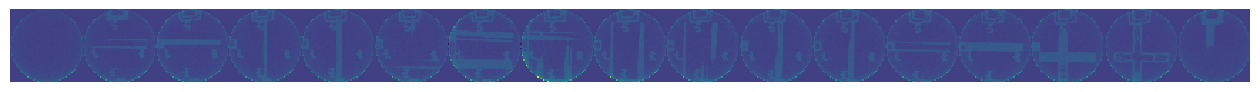

In [8]:
A1r = A1[:, :, 330:-170]
print(A1r.shape)
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A1r, mode, 30, decimate=10); 

In [9]:
print(aff1)

[[ -0.07600000   0.00000000  -0.00000000   0.00000000]
 [ -0.00000000   0.07600000  -0.00000000 -38.83599854]
 [  0.00000000   0.00000000   0.07599640  67.81500244]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]


In [10]:
tools.ext.np.sum(aff1 ** 2, 0) ** 0.5

array([ 0.07600000,  0.07600000,  0.07599640, 78.15439424])

In [11]:
A1r.dtype

dtype('float64')

In [12]:
t1 = time.time()
(A2, aff2) = tools.compute_subresolution_A1_aligned(
    # A1, (0.391, 0.391, 0.391), (2.5, 2.5, 2.5), nrand=1000)
    A1r, (0.076, 0.076, 0.076), (1.25, 1.25, 1.25), nrand=1000)
t2 = time.time()
print(t2 - t1)

18.235532760620117


In [13]:
A2.shape

(32, 32, 31)

In [14]:
A20 = A2.copy()

In [15]:
(A0, aff0) = tools.load_template("../templates/template-phantom-ct_resolution-1250.nii.gz")

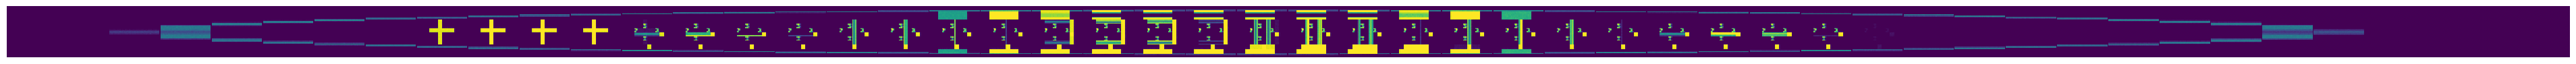

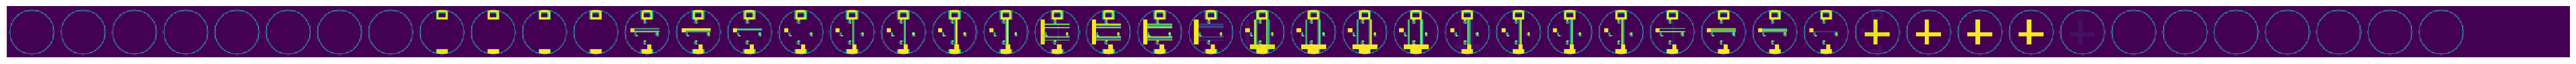

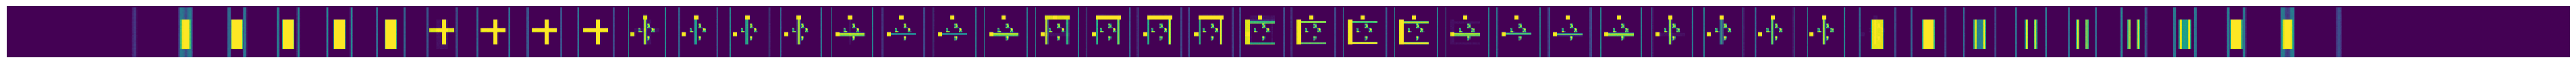

In [16]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0, mode); 

In [17]:
A0.shape

(49, 49, 49)

In [18]:
A0r = A0[9:-9, 9:-9, 9:-9]
print(A0r.shape)
patterns = tools.compute_patterns(A0r)

(31, 31, 31)


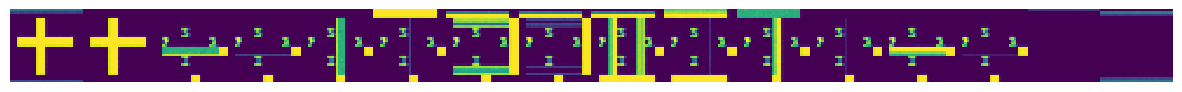

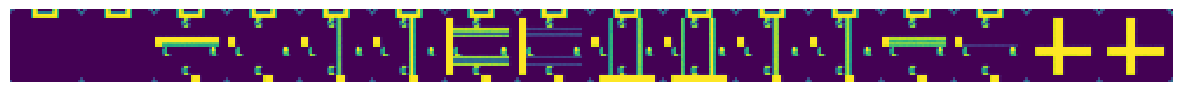

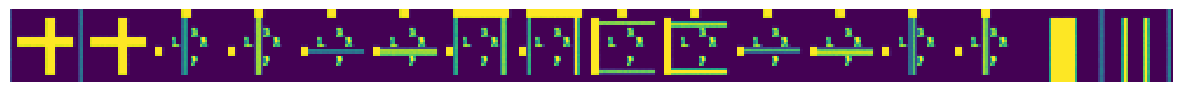

In [19]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0r, mode, step=2); 

In [20]:
A2 = tools.ext.np.zeros((45, 45, 45))
A2[7: -6, 7: -6, 7: -7] = A20[...]

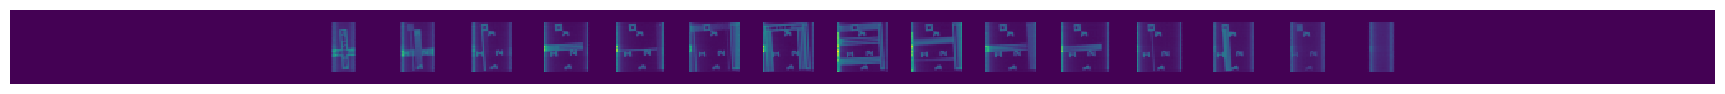

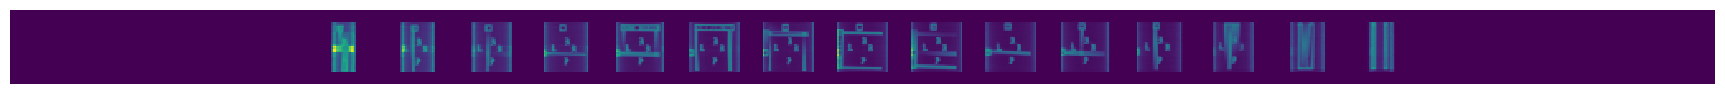

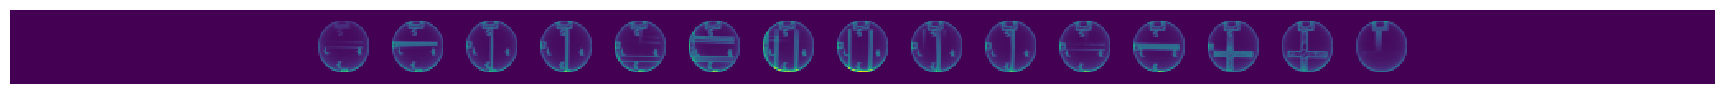

In [21]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A2, mode, decimate=1, step=2); 

In [22]:
res = {}
t1 = time.time()
for k in patterns: 
    Ak = patterns[k]
    ck = tools.compute_A_inside_B_best_translation(Ak, A2)
    res[k] = {"i": ck[0], "j": ck[1], "k": ck[2], "c": ck[3]}
t2 = time.time()
print(t2 - t1)
df1 = tools.ext.pd.DataFrame(res)
df2 = df1.T
df3 = df2.sort_values(by="c")

95.39723372459412


In [23]:
df3

,i,j,k,c
"True_True_True_(0, 1, 2)",4.0,7.0,7.0,0.361078
"False_False_False_(1, 0, 2)",3.0,9.0,4.0,0.367070
"True_False_True_(1, 0, 2)",4.0,2.0,6.0,0.371896
"False_False_True_(1, 0, 2)",4.0,8.0,7.0,0.372239
"True_False_False_(1, 0, 2)",4.0,2.0,7.0,0.372587
"True_False_True_(0, 1, 2)",4.0,4.0,7.0,0.374892
"False_False_True_(0, 1, 2)",8.0,4.0,7.0,0.384265
"True_False_False_(0, 1, 2)",2.0,4.0,7.0,0.385460
"False_False_False_(0, 1, 2)",8.0,4.0,7.0,0.385837
"True_True_False_(0, 1, 2)",4.0,7.0,7.0,0.391445


In [24]:
print(aff1)

[[ -0.07600000   0.00000000  -0.00000000   0.00000000]
 [ -0.00000000   0.07600000  -0.00000000 -38.83599854]
 [  0.00000000   0.00000000   0.07599640  67.81500244]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]


In [25]:
(flips1, orientations1) = tools.compute_flips_permutations(aff1)
print(flips1, orientations1)

[True, False, False] [np.int64(0), np.int64(1), np.int64(2)]


In [26]:
(flips2, orientations2) = ([False, False, False], [0, 2, 1])

In [27]:
tools.test_flips_orientations(flips1, flips2, orientations1, orientations2)

'F...FF'

In [28]:
tools.ext.reload(tools)

<module 'tools' from '/home/becqg/data/2024Phantom3D/derivatives/1-validate-orientations/code/tools.py'>

In [29]:
aff1r = tools.compute_transformed_affine(aff1, flips2, orientations2) 

In [30]:
print(aff1r)

[[  0.07600000   0.00000000   0.00000000   0.00000000]
 [  0.00000000   0.00000000   0.07599640  67.81500244]
 [  0.00000000   0.07600000   0.00000000 -38.83599854]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]
